<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day01_practice2_%EA%B8%B0%EC%B4%88%EC%88%98%ED%95%99_autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

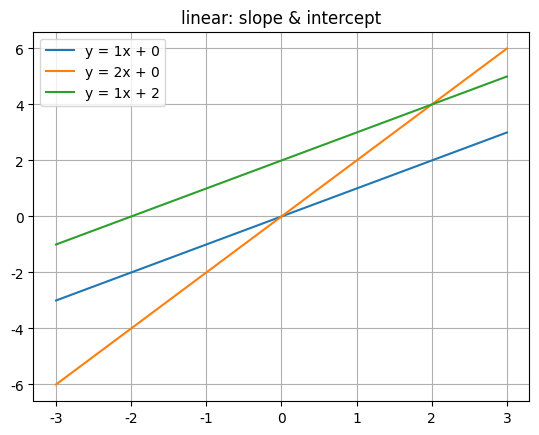

기울기 a가 커지면 가파라지고, b는 위아래로 평행이


In [12]:
# 셀 1. 일차 함수 - 기울기와 y 절편
# y = ax + b (a: 기울기, b: y 절편)
# y = wx + b (w: 가중치, b: 편향) - 선형회귀

x = torch.linspace(-3,3,100) # -3부터 3까지 100개 점
for a, b in [(1,0), (2,0), (1,2)]:
  y=a*x+b
  plt.plot(x,y,label=f"y = {a}x + {b}") # x와 y변수의 데이터를 사용하여 선 그래프 그리기

plt.legend(); plt.grid(True); plt.title("linear: slope & intercept")
plt.savefig("plot1_linear.png")
plt.show()
print("기울기 a가 커지면 가팔라지고, b는 위아래로 평행이")

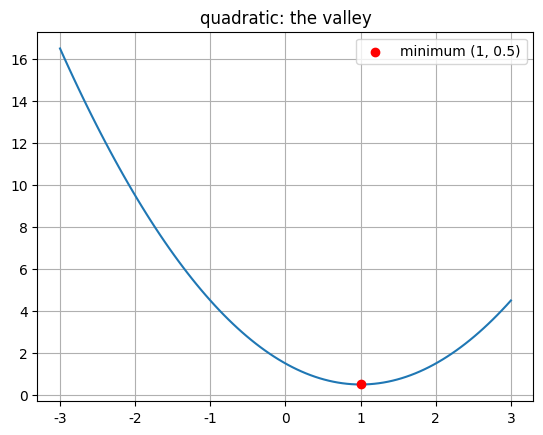

손실 함수의 골짜기 모양 - 빨간 점(최솟값)이 학습의 목적지


In [13]:
# 셀 2. 이차 함수와 최솟값
# 손실함수 : 인공지능 모델이 예측한 값과 실제 정답의 차이를 숫자로 계산하여,
#            모델의 성능이 얼마나 나쁜지 평가하는 기준
# 딥러닝의 손실 함수는 대게 '아래로 볼록한 골짜기' 모양
# 학습 - 이 골짜기의 가장 낮은 점(최솟값)을 찾아 내려가는 것.
# 함숫값에서는 기울기가 0 입니다. <- 미분필요

y = (x -1) **2 + 0.5 # 꼭짓점이 (1, 0.5) 인 이차 함수

plt.plot(x,y)
plt.scatter([1], [0.5], color="red", zorder=5, label="minimum (1, 0.5)")
plt.legend(); plt.grid(True); plt.title("quadratic: the valley")
plt.savefig("plot2.quadratic.png")
plt.show()
print("손실 함수의 골짜기 모양 - 빨간 점(최솟값)이 학습의 목적지")

In [16]:
# 셀 3. 미분 - 순간 변화
# f(x) = x² 의 미분은 f'(x) = 2x (공식)

def f(x):
  return x ** 2

x0 = torch.tensor(3.0) # 스칼라 값
h = 1e-5               # 아주 작은 수 0.00001 (10의 -5승)
수치미분 = (f(x0 + h) - f(x0)) / h # (변화량 y) / (변화량 x)
print(f"f(x)=x² 의 x=3 에서의 기울기")
print(f" 미분 공식(2x)   : {2 * x0.item(): .4f}") # .item()은 PyTorch 텐서인 x0의 값을 Python 숫자로 변환
print(f" 수치 근사   : {수치미분.item(): .4f}")

# 둘이 거의 같음 -> 미분 = 순간 변화

f(x)=x² 의 x=3 에서의 기울기
 공식(2x)   :  6.0000
 수치 근사   :  6.0081


In [17]:
# 셀 4. autograd - Pytorch 가 미분을 대신한다

x0 = torch.tensor(3.0, requires_grad=True) # 이 텐서에 대한 미분을 추적해라

y = x0 ** 2     # y = x² (PyTorch가 계산 과정을 기록 중)
y.backward()    # 역방향으로 미분 실행
# y 텐서로부터 역방향 전파 (backward propagation)을 시작하여, x0 텐서까지의 모든 연산에 대한 기울기를 계산
# 즉, y를 x0에 대해 미분한 값(dy/d=0)이 계산, 이 기울기 값은 x0.grad에 저장

# backward() 호출을 통해 계산된 w0의 기울기(w0.grad)를 출력

print("\n autograd가 구현 dy/dx:", x0.grad.item())
# 미분 공식 · 수치근시 · autograd 세 값이 모두 6


 autograd가 구현 dy/dx: 6.0


In [21]:
# 셀 5. 편미분 - 변수가 2개일 때

# f(w, b) = w² + 3b   →  ∂f/∂w = 2w,  ∂f/∂b = 3
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

f_val = w ** 2 + 3 * b
f_val.backward()

print('n\편미분 결과')
print('∂f/∂w=', w.grad.item(), "(미분공식 2w = 4)")
print("∂f/∂b=", b.grad.item(), "(미분공식 3)")

# 신경망의 가중치는 수백만 개 = 변수가 수백만 개인 편미분.


n\편미분 결과
∂f/∂w= 4.0 (미분공식 2w = 4)
∂f/∂b= 3.0 (미분공식 3)


In [24]:
# 셀 6. 경사 하강법 맛보기 - 골짜기를 실제로 내려가 보자

x = torch.tensor(4.0, requires_grad=True) # 아무 데서나 출발
ir = 0.1 # 학습율: 한 걸음의 크기
경로 = []

for stop in range(30):
  y = (x - 1) **2 + 0.5 # y = (x-1)² + 0.5
  y.backward() # 미분 y' = 2(x-1) -> x.grad = 2*(4-1) = 6

  with torch.no_grad(): # PyTorch의 자동 미분 추적을 비활성화, 단순히 x의 위치 이동 자체는 기록하지 않음
    x -= ir * x.grad  # 새로운 x = 4 - (0.1 * 6)
                      # 경사 하강법의 목표는 산의 가장 낮은 골짜기(최솟값)를 찾아 내려가는 것. 함수 값이 가장 빠르게 감소하는 방향으로 이동
                      # 기울기 값이 음수(-)를 곱하여 '기울기 반대 방향'으로 이동하는 이유

  x.grad.zero_() # 기울기 초기화 (누적 방지) - PyTorch응 backward()가 호출될 떄마다 기울기를 누적, 다음 스텝에서 새로운 기울기를 정확히 계

  경로.append(x.item())


print("\n경사 하강 경로 (30걸음):")
print("출발 4.0 ->", "->".join(f"{v:.2f}" for v in 경로[::6]), f"-> {경로[-1]:.4f}")
print("최소값의 위치 x=1에 도착")


경사 하강 경로 (30걸음):
출발 4.0 -> 3.40->1.63->1.16->1.04->1.01 -> 1.0037
최소값의 위치 x=1에 도착


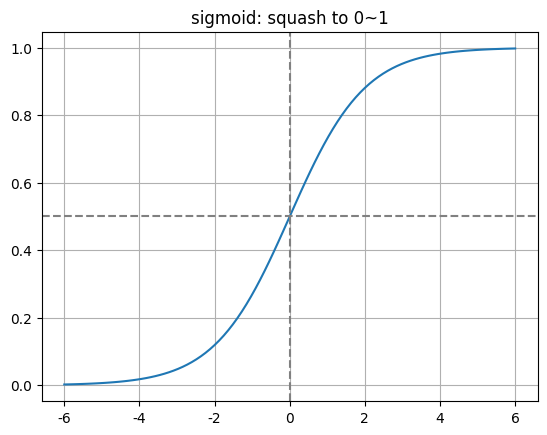

sigmoid(-6): 0.0025 =0
sigmoid(0): 0.5000 =0.5
sigmoid(6): 0.9975 =1


In [28]:
# 셀 7. 시그모이드 함수 - 활성화 함수는 신경망의 각 뉴런에서 비선형성을 부여하고 출력 값을 변환하는 역할
# 시그모이드: 어떤 수든 0~1 사이로 눌러 낳는 함수

x = torch.linspace(-6, 6, 100)
sig = torch.sigmoid(x)

plt.plot(x, sig)
plt.axhline(0.5, color='gray', ls="--"); plt.axvline(0, color="gray", ls="--")
plt.grid(True); plt.title("sigmoid: squash to 0~1")
plt.savefig("plot3_sigmoid.png")
plt.show()

print(f"sigmoid(-6): {torch.sigmoid(torch.tensor(-6.0)).item():.4f} =0")
print(f"sigmoid(0): {torch.sigmoid(torch.tensor(0.0)).item():.4f} =0.5")
print(f"sigmoid(6): {torch.sigmoid(torch.tensor(6.0)).item():.4f} =1")